## **Import Libraries**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## **Create Sample Dataset**

In [2]:
y_ture = 0 #actual value
y_predict = np.linspace(-10,10,100)
error = y_predict - y_ture

## **Implement Loss Functions**

### 1. Mean Squared Error (MSE)

In [3]:
mse = error**2

### 2. Mean Absolute Error (MAE)

In [4]:
mae = np.abs(error)

### 3. Huber Loss

In [5]:
delta = 1

huber = np.where(
    np.abs(error) <= delta,
    0.5 * error**2,
    delta * (np.abs(error) - 0.5 * delta)
)

### 4. Binary Cross Entropy (BCE)

👉 For BCE, predictions must be between 0 and 1

In [6]:
y_true_bce = 1
y_pred_bce = np.linspace(0.01, 0.99, 100)

bce = - (y_true_bce * np.log(y_pred_bce) + 
         (1 - y_true_bce) * np.log(1 - y_pred_bce))

### 5. Categorical Cross Entropy (CCE)

In [7]:
y_true_cce = np.array([0, 1, 0])   # one-hot
y_pred_cce = np.array([0.1, 0.7, 0.2])

cce = -np.sum(y_true_cce * np.log(y_pred_cce))
print("CCE:", cce)

CCE: 0.35667494393873245


### 6. Sparse Categorical Cross Entropy (SCCE)

In [8]:
y_true_scce = 1  # class index
y_pred_scce = np.array([0.1, 0.7, 0.2])

scce = -np.log(y_pred_scce[y_true_scce])
print("SCCE:", scce)

SCCE: 0.35667494393873245


## ***Visualization***

### Plot Regression Losses (MSE vs MAE vs Huber)

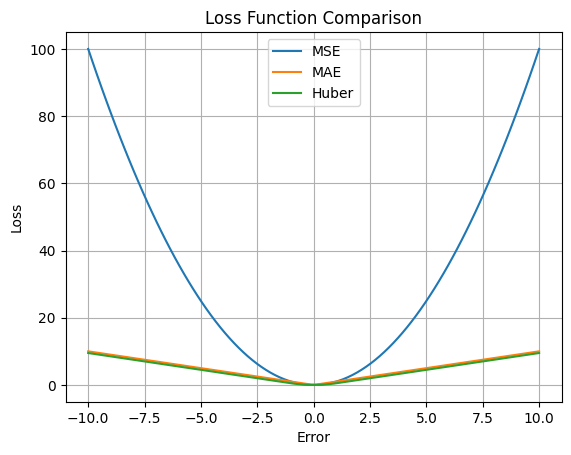

In [11]:
plt.figure()

plt.plot(error, mse, label="MSE")
plt.plot(error, mae, label="MAE")
plt.plot(error, huber, label="Huber")

plt.title("Loss Function Comparison")
plt.xlabel("Error")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

### Plot BCE

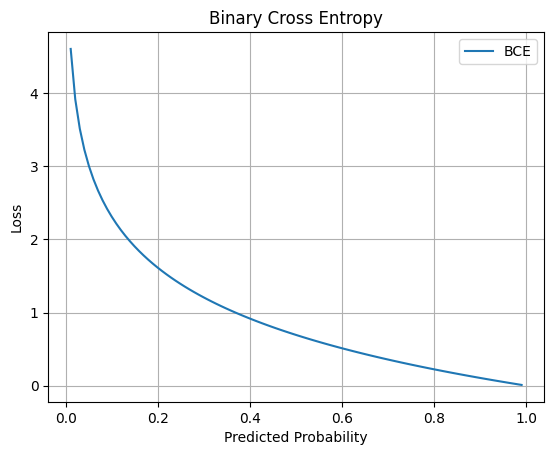

In [12]:
plt.figure()

plt.plot(y_pred_bce, bce, label="BCE")

plt.title("Binary Cross Entropy")
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

## **Real Deep Learning Usage**

In [14]:
import tensorflow as tf
from tensorflow.keras.losses import MeanSquaredError, MeanAbsoluteError, Huber
from tensorflow.keras.losses import BinaryCrossentropy, CategoricalCrossentropy, SparseCategoricalCrossentropy

# Initialize loss functions
mse = MeanSquaredError()
mae = MeanAbsoluteError()
huber = Huber()

bce = BinaryCrossentropy()
cce = CategoricalCrossentropy()
scce = SparseCategoricalCrossentropy()

# -----------------------------
# Sample Data
# -----------------------------

# Regression (MSE, MAE, Huber)
y_true_reg = tf.constant([1.0, 2.0, 3.0])
y_pred_reg = tf.constant([1.5, 2.5, 2.0])

# Binary Classification (BCE)
y_true_bce = tf.constant([1.0, 0.0, 1.0])
y_pred_bce = tf.constant([0.9, 0.2, 0.8])

# Categorical (One-hot for CCE)
y_true_cce = tf.constant([[0,1,0], [1,0,0]])
y_pred_cce = tf.constant([[0.1,0.7,0.2], [0.8,0.1,0.1]])

# Sparse (Integer labels for SCCE)
y_true_scce = tf.constant([1, 0])
y_pred_scce = tf.constant([[0.1,0.7,0.2], [0.8,0.1,0.1]])

# -----------------------------
# Print Loss Values
# -----------------------------

print("MSE Loss:", mse(y_true_reg, y_pred_reg).numpy())
print("MAE Loss:", mae(y_true_reg, y_pred_reg).numpy())
print("Huber Loss:", huber(y_true_reg, y_pred_reg).numpy())

print("BCE Loss:", bce(y_true_bce, y_pred_bce).numpy())

print("Categorical Crossentropy Loss:", cce(y_true_cce, y_pred_cce).numpy())

print("Sparse Categorical Crossentropy Loss:", scce(y_true_scce, y_pred_scce).numpy())

MSE Loss: 0.5
MAE Loss: 0.6666667
Huber Loss: 0.25
BCE Loss: 0.18388253
Categorical Crossentropy Loss: 0.28990924
Sparse Categorical Crossentropy Loss: 0.2899092
